# EDA for New Data

This EDA will be broken down into three sections: general data exploration, univariate analysis, and multivariate analysis.

## Missing Values and Duplicates


In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# data reading in
raw_df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")
raw_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [160]:
# missing values

raw_df.isna().sum()

# duplicate values
raw_df.drop(columns=["Person ID"]).duplicated().sum()

np.int64(242)

So it seems as though this data is pretty clean in terms of missing values. It is therefore either synthetically generated or has already gone through pre-processing. I could turn those NAs in Sleep Disorder to be a "None" class, but I will address that later.

In terms of duplcates, it seems that when taking the person id away, many observations are duplicated (242/374). This is quite concerning as things like heart rate, age, occupation, blood pressure, etc. are difficult to have duplicated exactly. I am wondering whether this is an error in the data.

In [161]:
# filtering in on the duplicate values
raw_df[raw_df.drop(columns = ["Person ID"]).duplicated()]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
11,12,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


OK. The fact that there are multiple female nurses with the exact same age, blood pressure, and sleep apnea means that there is an error with the data. For this reason, I will keep one of each duplicated row as a legitimate observation, and assume that the others were duplicates.

In [162]:
modified_df = raw_df.drop_duplicates(subset = raw_df.columns.difference(["Person ID"])).copy()
modified_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,359,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,NaN
359,360,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,NaN
360,361,Female,59,Nurse,8.2,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
364,365,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


While I was going to wait and do this in a separate script for easier documentation, the variable names having spaces are quite cumbersome to work with, and frankly, against good variable naming conventions. Thus, the following section will change the names of the variables that have spaces in the names. After doing so, I will do a univariate analysis of the variables.

### Variable Renaming

In [163]:
rename_cols = {
    "Sleep Duration": "sleep_duration",
    "Sleep Disorder": "sleep_disorder",
    "Stress Level": "stress_level",
    "Quality of Sleep": "sleep_quality",
    "Physical Activity Level": "physical_activity_level",
    "Age": "age",
    "Occupation": "occupation",
    "Person ID": "person_id",
    "Gender": "gender",
    "BMI Category": "bmi_category",
    "Blood Pressure": "blood_pressure",
    "Heart Rate": "heart_rate",
    "Daily Steps": "daily_steps",
}
modified_df.rename(columns=rename_cols, inplace=True)

# check for correctness of renaming
modified_df.columns

write_path = "data/modified_sleep_health_and_lifestyle_dataset.csv"
modified_df.to_csv(write_path, index=False)

## Univariate Analysis

### Response Variables

Three variables of interest are Sleep Duration, Quality of Sleep, and Stress Level. I will observe their distributions and identify extreme observations/ potential outliers.

While I was going to wait and do this in a separate script for easier documentation, the variable names having spaces are quite cumbersome to work with, and frankly, against good variable naming conventions. Thus, the following section will change the names of the variables that have spaces in the names. After doing so, I will continue univariate analysis of the rest of the variables.

### Variable Renaming

sleep_duration
7.2    11
6.5    10
6.0     9
6.1     9
7.8     8
7.1     7
7.6     6
8.1     6
6.6     6
7.7     6
6.2     5
6.4     5
8.0     4
7.3     4
5.9     3
7.9     3
6.3     3
7.5     3
7.4     3
8.3     3
8.5     3
6.9     3
6.8     3
8.4     3
8.2     3
6.7     2
5.8     1
Name: count, dtype: int64

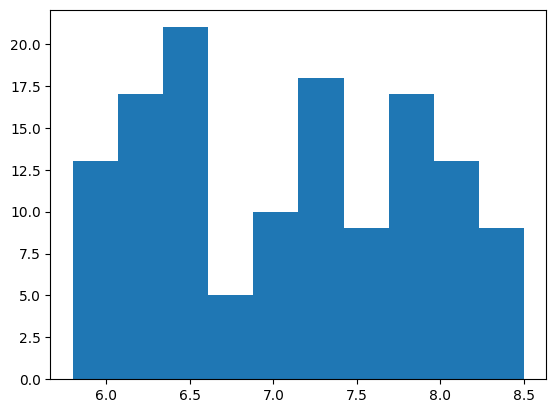

In [164]:
# Sleep Duration:

plt.hist(modified_df['sleep_duration'])
modified_df['sleep_duration'].value_counts()

What is concerning with this variable after plotting the histogram and looking more indepth into the individual values is two-fold. Firstly, the distribution of sleep duration looks trimodal within the histogram. This differs from our previous dataset, where observations were distributed normally. Secondly, the values of sleep duration are more specific than typically expected of real people to document. Generally, people like to round, and so it would be expected to see whole or .5 rounding. Yet, the top most documented duration ends with .2. While this could be attributed to sleep tracking devices, we might then expect missing data occurring, attributed to study participants neglecting to wear their device.

0      6
1      6
3      4
5      4
6      6
      ..
358    9
359    9
360    9
364    9
366    9
Name: sleep_quality, Length: 132, dtype: int64

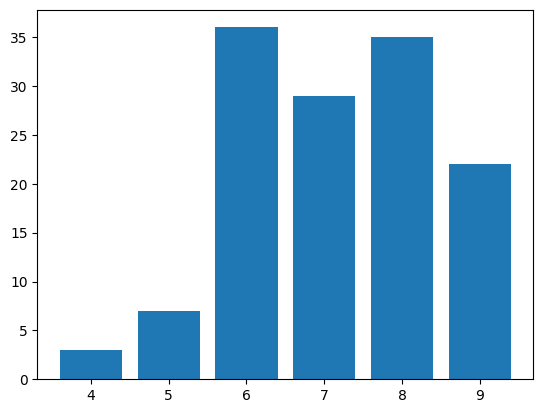

In [165]:
# Quality of Sleep

plt.bar(modified_df["sleep_quality"].value_counts().index, modified_df["sleep_quality"].value_counts().values)
modified_df['sleep_quality']


Quality of sleep is definitely plotted on a scale. The data documentation does not specify what kind of scale or what the ranges of the original scale are. For the purposes of my analysis, I will have to make some assumptions based on what the other response variables reflect.

stress_level
8    24
7    22
3    22
4    22
6    21
5    21
Name: count, dtype: int64

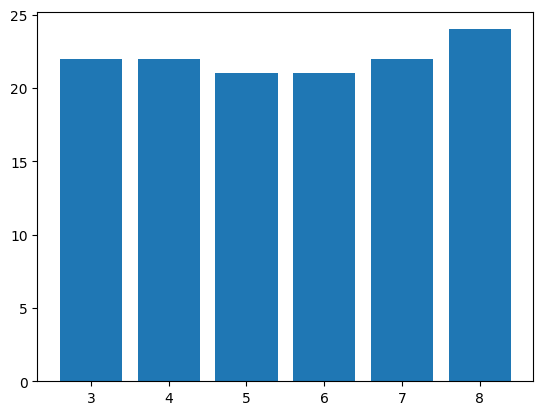

In [166]:
# stress level

plt.bar(modified_df['stress_level'].value_counts().index, modified_df['stress_level'].value_counts().values)
modified_df['stress_level'].value_counts()

The same problems with quality of sleep arise with stress level. This seems to be set at a scale as well, but no description of the scale or the range is given. To perhaps gain a better understanding of these two variables, I will take a look at the sleep disorder variable to see if I can identify patterns.

In [167]:
# Sleep Disorder

modified_df[modified_df["sleep_disorder"]=="Insomnia"]

,person_id,gender,age,occupation,sleep_duration,sleep_quality,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
18,19,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Insomnia
31,32,Female,30,Nurse,6.4,5,35,7,Normal Weight,130/86,78,4100,Insomnia
67,68,Male,33,Doctor,6.0,6,30,8,Normal,125/80,72,5000,Insomnia
94,95,Female,36,Accountant,7.2,8,60,4,Normal,115/75,68,7000,Insomnia
105,106,Male,36,Teacher,6.6,5,35,7,Overweight,129/84,74,4800,Insomnia
146,147,Male,39,Lawyer,7.2,8,60,5,Normal,130/85,68,8000,Insomnia
147,148,Male,39,Engineer,6.5,5,40,7,Overweight,132/87,80,4000,Insomnia
165,166,Male,41,Lawyer,7.6,8,90,5,Normal,130/85,70,8000,Insomnia


From this data and some logical deductions (I still may be wrong), I am going to assume that the scale of both Quality of Sleep and Stress Level are from 1-10. Additionally, the higher the value, the higher the quality of sleep or stress level respectively. Thus, a 1 would represent low sleep quality under the Quality of Sleep variable or a low stress level under the Stress Level variable.

Assuming these scales and after observing the data, I see class imbalances (if we were to use these as classes). We could also keep them as numeric to preserve scale/ order.

I also think that the sleep disorders would be good to explore for patterns. This could turn into a response variable for a classification hypothesis.

<BarContainer object of 2 artists>

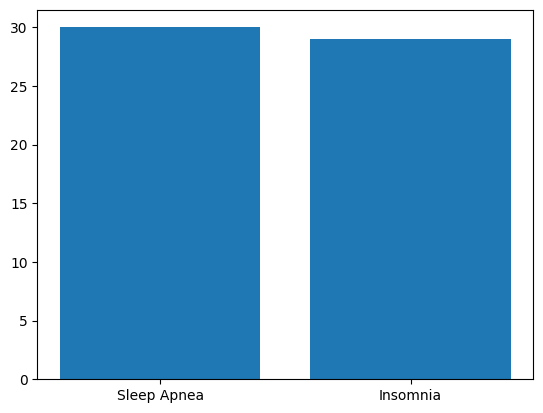

In [168]:
# Exploring Sleep disorder
modified_df[modified_df['sleep_disorder']=='Insomnia']
plt.bar(modified_df['sleep_disorder'].value_counts().index, modified_df['sleep_disorder'].value_counts().values)

### Other Variables

In [169]:
modified_df.columns
# gender
#plt.bar(modified_df.gender.value_counts().index, modified_df.gender.value_counts().values) 
# # very even distribution

# age
#plt.hist(modified_df.age) 
# # good distribution of ages overall, though a bit uneven

# occupation
# plt.bar(modified_df.occupation.value_counts().index, modified_df.occupation.value_counts().values) 
# # it is not pretty, but gets the job done for now. seems like there are a range of different occupations
# # some I would classify as high stress


Index(['person_id', 'gender', 'age', 'occupation', 'sleep_duration',
       'sleep_quality', 'physical_activity_level', 'stress_level',
       'bmi_category', 'blood_pressure', 'heart_rate', 'daily_steps',
       'sleep_disorder'],
      dtype='object')

In [170]:
# physical activity level
# plt.bar(modified_df.physical_activity_level.value_counts().index, modified_df.physical_activity_level.value_counts().values) 
# # spikes in certain places, but overall a good distribution of physical activity levels

# BMI category
# plt.bar(modified_df.bmi_category.value_counts().index, modified_df.bmi_category.value_counts().values) 
# # extra class of normal weight, will merge with normal class; tail of sorts

# blood pressure
#plt.bar(modified_df.blood_pressure.value_counts().index, modified_df.blood_pressure.value_counts().values) 
# # will need to merge some here? maybe normal, high and low? could keep it, but would like to separate it out
# # into diastolic and systolic.

# heart rate
# plt.hist(modified_df.heart_rate) 
# # most normal, some a bit higher but not too bad

# daily steps
# plt.hist(modified_df.daily_steps) 
# # varied distribution, expect high correlation with physical activity level and occupation, but will need to check



Ok, so initial univariate analysis will stop here for now. I will quickly modify the data to change the BMI classes and separate out systolic and diastolic blood pressures.

In [171]:
modified_df['systolic'] = modified_df['blood_pressure'].str.split('/').str[0]
modified_df['diastolic'] = modified_df['blood_pressure'].str.split('/').str[1]
modified_df['bmi_category'] = modified_df['bmi_category'].replace('Normal Weight', 'Normal')
modified_df['bmi_category'] = modified_df['bmi_category'].replace('Obese', 'Overweight')
modified_df.drop(columns=['blood_pressure'], inplace=True)
modified_df['sleep_disorder'] = modified_df['sleep_disorder'].fillna("NA")
modified_df=modified_df.astype({'systolic': 'float', 'diastolic': 'float'})

# overwriting modified_sleep....csv with the new columns and changes
modified_df.to_csv(write_path, index=False)
modified_df.columns

Index(['person_id', 'gender', 'age', 'occupation', 'sleep_duration',
       'sleep_quality', 'physical_activity_level', 'stress_level',
       'bmi_category', 'heart_rate', 'daily_steps', 'sleep_disorder',
       'systolic', 'diastolic'],
      dtype='object')

## Multivariate Analysis:

I will split this analysis into two components: correlation among the numeric variables and then independent analysis of the categorical variables.

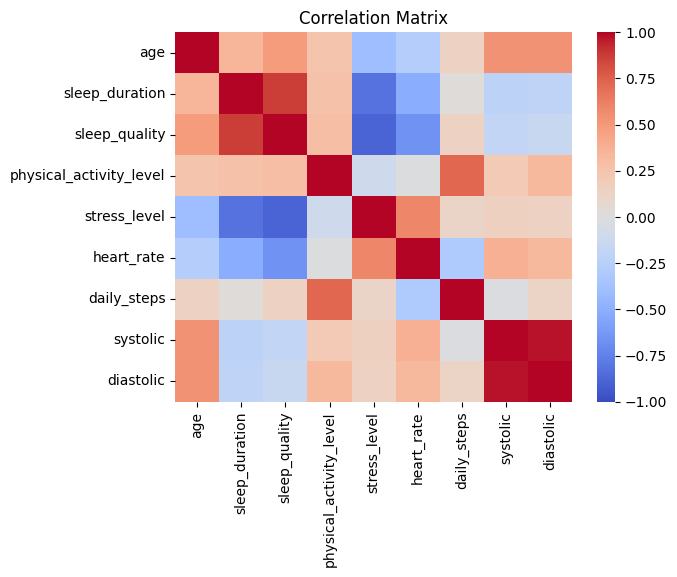

In [172]:
import seaborn as sns
sns.heatmap(modified_df.select_dtypes('number').drop('person_id', axis=1).corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

From this correlation heatmap, it does seem as though there are certain variables highly correlated with one another. Specifically, sleep quality, sleep duration, heart rate and stress level have some correlation. For the purposes of future analysis, it will be important to keep in mind how sleep quality, duration and stress levels are related as we use them for potential response variables in predictive modeling. Lastly, this is quite expected in the real-world, but physical activity level and daily steps overlap as well.

## Exploring Relationships with Categorical Variables

This section will explore the segmentation of observations using variables such as gender, age, occupation, and sleep disorders more and the qualities of people whom have these disorders. The numeric variables previously examined in the correlation heatmap above such as BMI, heart rate, and blood pressure will be observed for each segment.

In [173]:
# gender

modified_df.drop(
    columns=['person_id', 'occupation', 'bmi_category', 
             'sleep_disorder'], axis=1).groupby('gender').mean()

modified_df[['occupation', 'gender']].value_counts() 
modified_df[['bmi_category', 'gender']].value_counts()
modified_df[['sleep_disorder', 'gender']].value_counts()
modified_df[['gender']].value_counts()


gender
Male      67
Female    65
Name: count, dtype: int64

With gender in real-world data, these values would need to be normalized with the total counts of each gender within the data. However, the number of people within each gender is relatively balanced (off by 2 to be perfectly balanced) within this dataset. From the means and counts, there do seem to be differences between gender. This will further be examined later in the analysis.

In [174]:
# occupation

modified_df.drop(
    columns=['person_id', 'gender', 'bmi_category', 
             'sleep_disorder'], axis=1).groupby('occupation').mean()
 
modified_df[['bmi_category', 'occupation']].value_counts()/modified_df[['occupation']].value_counts()
modified_df[['sleep_disorder', 'occupation']].value_counts()/modified_df[['occupation']].value_counts()


sleep_disorder  occupation          
NA              Accountant              0.727273
Insomnia        Accountant              0.272727
NA              Doctor                  0.791667
Sleep Apnea     Doctor                  0.125000
Insomnia        Doctor                  0.083333
NA              Engineer                0.772727
Insomnia        Engineer                0.181818
Sleep Apnea     Engineer                0.045455
NA              Lawyer                  0.666667
Sleep Apnea     Lawyer                  0.200000
Insomnia        Lawyer                  0.133333
NA              Manager                 1.000000
Sleep Apnea     Nurse                   0.586207
NA              Nurse                   0.310345
Insomnia        Nurse                   0.103448
Sleep Apnea     Sales Representative    1.000000
Insomnia        Salesperson             0.666667
NA              Salesperson             0.222222
Sleep Apnea     Salesperson             0.111111
NA              Scientist       

The same normalization would need to be applied to this variable as the distribution of the occupations is imbalanced. From the means and proportions, there does seem to be differences among the occupations. These patterns will further be explored in the later analysis. 

In [177]:
# bmi

modified_df.drop(
    columns=['person_id', 'gender', 'occupation', 
             'sleep_disorder'], axis=1).groupby('bmi_category').mean()
 
#modified_df[['sleep_disorder', 'bmi_category']].value_counts()/modified_df[['bmi_category']].value_counts()

,age,sleep_duration,sleep_quality,physical_activity_level,stress_level,heart_rate,daily_steps,systolic,diastolic
bmi_category,,,,,,,,,
Normal,37.698630,7.342466,7.506849,57.698630,5.246575,69.506849,6853.424658,123.246575,80.547945
Overweight,45.372881,6.761017,6.711864,59.254237,5.898305,73.305085,6371.186441,134.694915,89.474576


There does seem to be an increase in sleep disorders with those who are overweight. Additionally, certain body metrics (as expected)-- such as heart rate, systolic, and diastolic -- do differ.


## Conclusion

This concludes the second EDA. The next phase of this project will involve establishing a framework for the analysis of this data, including key objectives or questions this project will attempt to answer.